# Dengesiz Veri Kümeleri

Veri bilimi kurslarında kullanılan veri setlerinin bir çoğu **dengelidir**. Buradaki temel amaç, öğrenme hedefiyle ilgili olmayan ek bilgiler hakkında endişelenmeden algoritmanın nasıl çalıştığını öğreniyor olmamızdır. Ancak gerçek veri setleriyle çalışmaya başladığınızda, verilerin aslında ne kadar **karmaşık** ve **dengesiz** olduklarını göreceksiniz.

Biz de bu dersimizde, sınıflandırma problemlerinde de konuştuğumuz hata metriklerini kullanarak dengesiz veri kümeleriyle nasıl çalışmamız gerektiğini konuşuyor olacağız.

Bu dersin sonunda şunları yapabiliyor olmayı hedefliyoruz:

1. Dengesiz veri setlerini anlamak
2. Dengesiz veri setlerinin ne tarzda sorunlara sebep olabileceği hakkında bilgi sahibi olmak
3. Ve bu sorunları elimine etmek için kullanacağımız teknikleri ve mantıklarını kavramak

## Kütüphane Yüklemeleri

Eğer kendi local bilgisayarınızda çalışıyorsanız, bu notebookumuzda olan çalışmaları yapabilmemiz için ilk olarak `mlxtend` ve `imblearn` kütüphanelerini bilgisayarınıza kurmayı unutmayın!

```python
!pip install mlxtend
!pip install imblearn
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.datasets import make_classification
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC, SVC
from xgboost import XGBClassifier
from collections import Counter
from mlxtend.plotting import plot_decision_regions

Son olarak da çalışmalara başlamadan önce, notebook içerisinde bir çok hata matrisi görüp onlardan elde ettiğimiz sonuçları daha anlaşılır bir şekilde kıyaslamamız için basit bir `print_confusion_matrix` fonksiyonu oluşturalım.

In [2]:
def print_confusion_matrix(confusion_matrix, class_names, figsize = [12,8], fontsize=18):
    """Prints a confusion matrix, as returned by sklearn.metrics.confusion_matrix, as a heatmap.
    
    Arguments
    ---------
    confusion_matrix: numpy.ndarray
        The numpy.ndarray object returned from a call to sklearn.metrics.confusion_matrix. 
        Similarly constructed ndarrays can also be used.
    class_names: list
        An ordered list of class names, in the order they index the given confusion matrix.
    figsize: tuple
        A 2-long tuple, the first value determining the horizontal size of the ouputted figure,
        the second determining the vertical size. Defaults to [12,8].
    fontsize: int
        Font size for axes labels. Defaults to 18.
        
    Returns
    -------
    matplotlib.figure.Figure
        The resulting confusion matrix figure
    """
    
    df_cm = pd.DataFrame(confusion_matrix, index=class_names, columns=class_names, )
    fig = plt.figure(figsize=figsize)
    
    try:
        heatmap = sns.heatmap(df_cm, annot=True, fmt="d")
    except ValueError:
        raise ValueError("Confusion matrix values must be integers.")
        
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right', fontsize=fontsize)
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right', fontsize=fontsize)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    return fig

## Metric Trap

Elinizde 2 tane sınıftan oluşan bir veri seti olduğunu düşünün. Ancak bu veri setinde bir sınıfın yoğunluğu **%99**, diğer sınıfın ise **%1**'de kalsın. Böyle bir durumda oluşturduğumuz bir model muhtemelen **%99 accuracy** değeriyle karşımıza çıkacaktır. Ancak hata matrisini incelediğinizde ise, yapılan tüm tahminlerin **%99 yoğunlukta olan sınıfa göre** yapıldığını göreceksiniz. İşte biz buna **metric trap** diyoruz. Accuracy -özellikle dengesiz veri setlerinde- bizim işimizi görmüyor!

Şimdi de bu konuştuklarımızı, notebookdaki örnek veri setimiz üzerinden tekrardan değerlendirelim.

In [3]:
imbalanced_df = pd.read_csv('data/train.csv')
imbalanced_df

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,...,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,...,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,...,4,2,7,7,0,1,1,0,1,0
3,16,0,0,1,2,0,0,1,0,0,...,2,2,4,9,0,0,0,0,0,0
4,17,0,0,2,0,1,0,1,0,0,...,3,1,1,3,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595207,1488013,0,3,1,10,0,0,0,0,0,...,4,1,9,6,0,1,1,0,1,1
595208,1488016,0,5,1,3,0,0,0,0,0,...,4,1,3,8,1,0,1,0,1,1
595209,1488017,0,1,1,10,0,0,1,0,0,...,3,2,2,6,0,0,1,0,0,0
595210,1488021,0,5,2,3,1,0,0,0,1,...,4,1,4,2,0,1,1,1,0,0


In [4]:
target_count = imbalanced_df.target.value_counts()
target_count

0    573518
1     21694
Name: target, dtype: int64

Veri setimizdeki **hedef sütunumuza ilişkin dağılımı** daha iyi anlamak için görsellerimizden yararlanabiliriz.

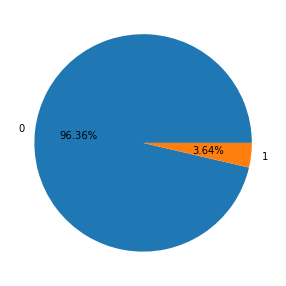

In [5]:
plt.figure(figsize=[8,5])
plt.pie(target_count, labels=[0,1], autopct='%.2f%%');

Pie Chart görselinden de çok net bir şekilde görüldüğü gibi, **elimizde oldukça dengesiz dağılan bir veri seti** var. O zaman şimdi, hedef sütununa ilişkin bu şekilde dağılım gösteren bir veri setinden modelimizi oluşturalım ve elde ettiğimiz sonuçları beraber tartışalım.

In [6]:
X = imbalanced_df.iloc[:, 2:]
y = imbalanced_df.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
# stratify=y parametresi veri setini bölme aşamasında train ve testteki label dağılımının dengeli olacağını söyler

XGBoost algoritması genellikle diğer makine öğrenmesi algoritmalarından daha iyi çözümler sağladığı bilinmektedir. Ortaya çıkışından bu yana da, yapılandırılmış verilerle başa çıkmak için son teknoloji makine öğrenmesi algoritması haline gelmiştir. Bu yüzden ilk sınıflandırma denememizde XGBoost'u kullanalım.

In [7]:
xgb = XGBClassifier().fit(X_train, y_train)

In [8]:
y_pred = xgb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {round(accuracy, 4)*100}')

Model Accuracy: 96.35000000000001


Modelimizin accuracy değerine baktığımızda oldukça iyi bir başarı yakalamış gibi görünüyoruz. Ama özellikle dengesiz veri setlerinde buna doğrudan kanmamız gerektiğini konuşmuştuk. 

O zaman, hata matrisine bakarak olayın asıl iç yüzünü anlayalım.

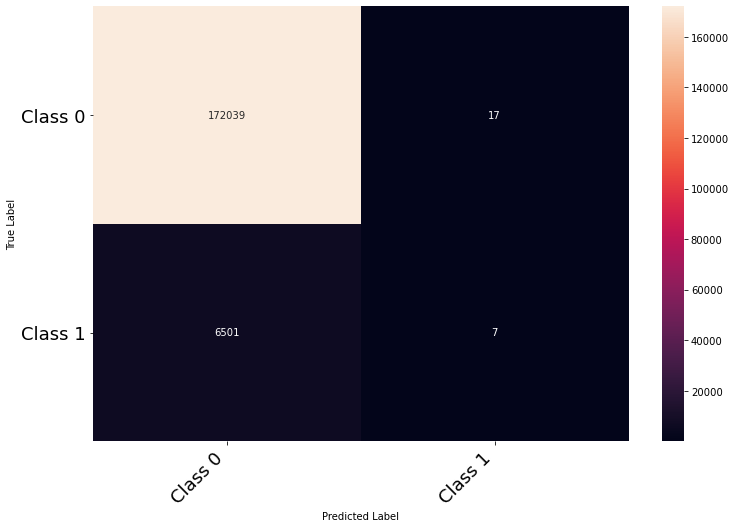

In [9]:
conf_mat = confusion_matrix(y_true=y_test, y_pred=y_pred)
cm = print_confusion_matrix(conf_mat, ['Class 0', 'Class 1'])

Evet gerçekten de accuracy değerine kanmamalıymışız! Çünkü veri setimizde **6508 tane olan Class 1'de sadece 7 tane doğru tahminde bulanabilmişiz** hem de XGBoost algoritmasını kullanmamıza rağmen! Korkunç!

İşte bu durum dengesiz veri kümelerinde çalışırken karşımıza sürekli çıkan bir sorundur. Ama neyse ki bu tarz durumların önüne geçebilmemiz için çeşitli yöntemlerimiz var. Hadi gelin şimdi bunların ne olduklarını konuşalım.

# 1. Yöntem - Oversampling

Adından da anlaşabileceği gibi, **oversampling azınlıkta olan sınıftaki verilerin sayısını çoğunluk olan sınıftaki verilerin sayısına eşitler**. Bu sayede de, dengesiz veri seti sorunundan kurtulmuş oluruz. Peki nasıl mı? 

Eğer elimizde çok fazla veri yoksa azınlık sınıfının örneklerini artırabiliriz. Bu yöntemde **veri setinde herhangi bir bilgi kaybı yaşanmaz**. Ancak azınlık sınıfındaki veriler arttırıldığında, hem bu durum **eğitim süresini uzamasına** sebep olur, hem de **modelimizin overfittinge yakalanma şansını** da artırabilir.

- Hadi bir örnek üzerinden bu yöntemin nasıl işlediğini daha iyi anlamaya çalışalım.

İlk olarak kendimiz sentetik bir veri oluşturalım, ardından bu verileri kullanarak modelimizi eğitelim ve oversampling yönteminin nasıl davrandığını kavramaya çalışalım.

In [10]:
# Sentetik bir veri seti oluşturma
X, y = make_classification(n_samples=5000, n_features=2, n_informative=2,
                           n_redundant=0, n_repeated=0, n_classes=2,
                           n_clusters_per_class=1, 
                           weights=[0.04, 0.96], # %4 ve %96 yoğunlukta 2 adet sınıf tanımlıyoruz
                           class_sep=0.2, random_state=42)

In [11]:
df = pd.DataFrame(X, columns=['column1', 'column2'])
df['label'] = y
df

,column1,column2,label
0,1.052104,-0.418229,1
1,-0.769686,0.971810,1
2,0.701224,-0.252568,1
3,0.867594,-0.298672,1
4,0.965436,-0.330174,1
...,...,...,...
4995,-1.046941,1.052886,1
4996,-0.095033,0.422672,1
4997,-0.482381,0.664244,1
4998,-0.855694,0.926287,1


In [12]:
df.label.value_counts()

1    4777
0     223
Name: label, dtype: int64

Evet elimizde gerçekten **%96'sı Class 1'e**, **%4'ü ise Class 0'a** ait bir veri seti var. Şimdi böyle bir veri setiyle modelimizi oluşturduğumuzda ortaya çıkan sonuçları daha iyi kavramaya çalışalım. İlk olarak hedef sütunumuzun değer dağılımını inceleyelim.

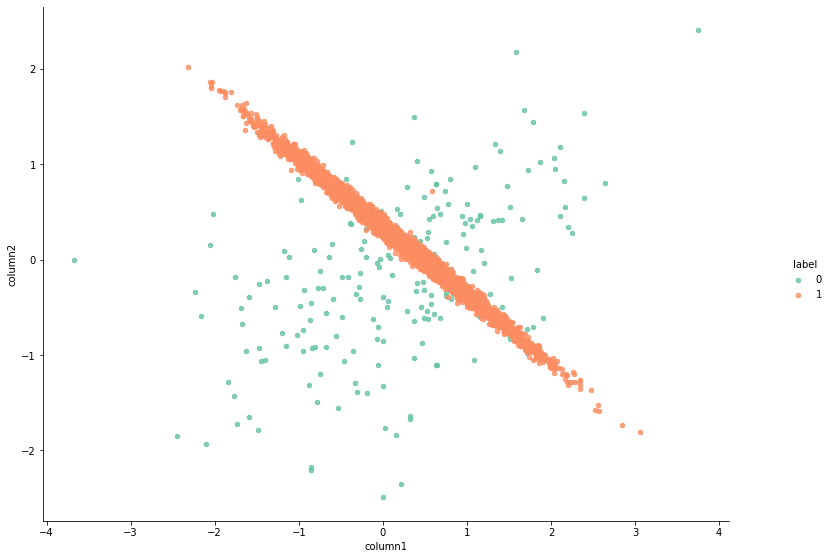

In [13]:
sns.lmplot(x='column1', y='column2', data=df, hue='label', palette='Set2', fit_reg=False, scatter_kws={'s': 20})
plt.gcf().set_size_inches(12,8);

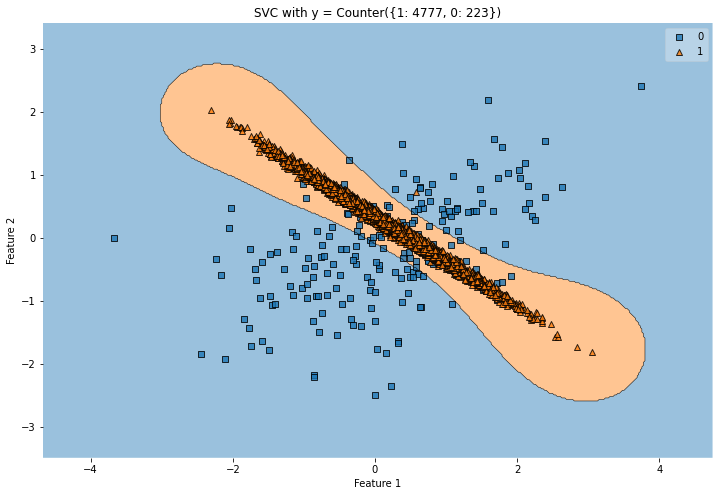

In [14]:
# Support Vector Classifier (SVC) algoritmasıyla modelimizi oluşturalım
svc = SVC().fit(X, y)
plot_decision_regions(X, y, svc)
plt.title(f'SVC with y = {Counter(y)}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.gcf().set_size_inches(12,8)

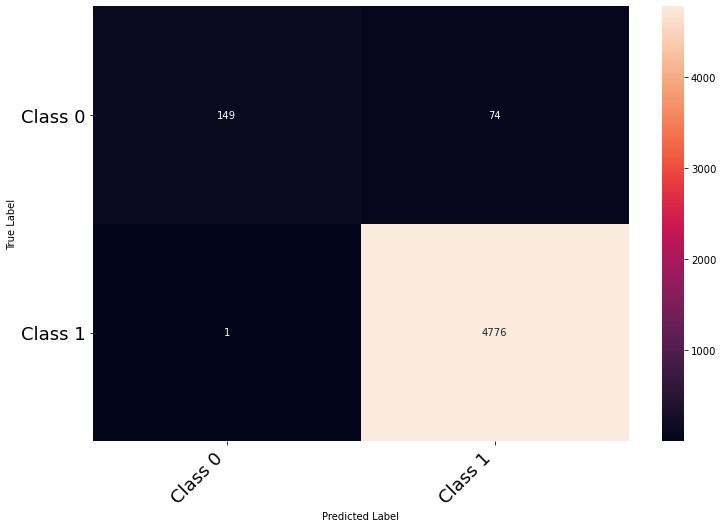

In [15]:
cm = print_confusion_matrix(confusion_matrix(y, svc.predict(X)), ['Class 0', 'Class 1'])

Hata matrisine baktığımızda çoğunluk olan **Class 1** sınıfında gerçekleştirilen tahminler çok yüksek oranlarda başarılı olduğunu, ancak azınlık olan **Class 0** sınıfında gerçekleştirilen tahminlerin ise o kadar başarılı olmadığını görüyoruz. Yani;

- Class 1'deki verileri tahmin etmekte yaklaşık **%99** gibi bir doğruluk yakalırken, Class 0'daki verileri tahmin etmekte yaklaşık ancak **%67** gibi bir doğruluk yakalanmıştır.

Şimdi asıl sormamız gereken soru şu: **Daha iyi bir model oluşturabilir miydik?**

- **Evet!** Azınlık olan sınıfımıza oversampling uygulayarak!

## 1.1. Random Oversampling

In [17]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler()
X_resampled, y_resampled = ros.fit_resample(X,y)

In [18]:
# Artık elimizde dengeli bir sınıf dağılımı var :)
Counter(y_resampled)

Counter({1: 4777, 0: 4777})

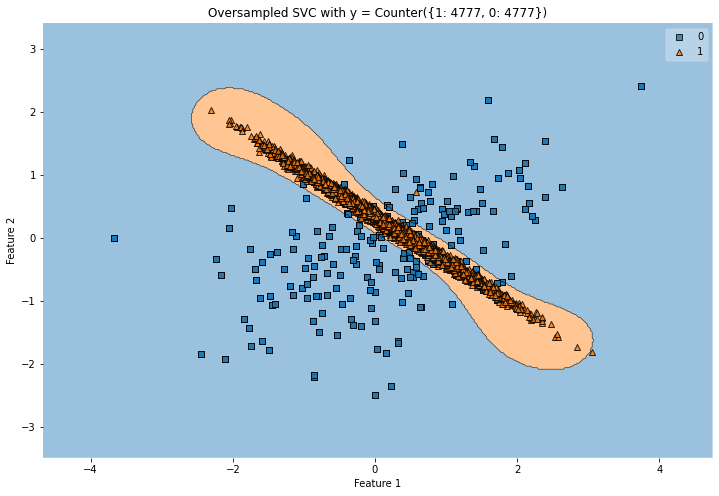

In [19]:
svc_ros = SVC().fit(X_resampled, y_resampled)
plot_decision_regions(X_resampled, y_resampled, svc_ros)
plt.title(f'Oversampled SVC with y = {Counter(y_resampled)}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.gcf().set_size_inches(12,8)

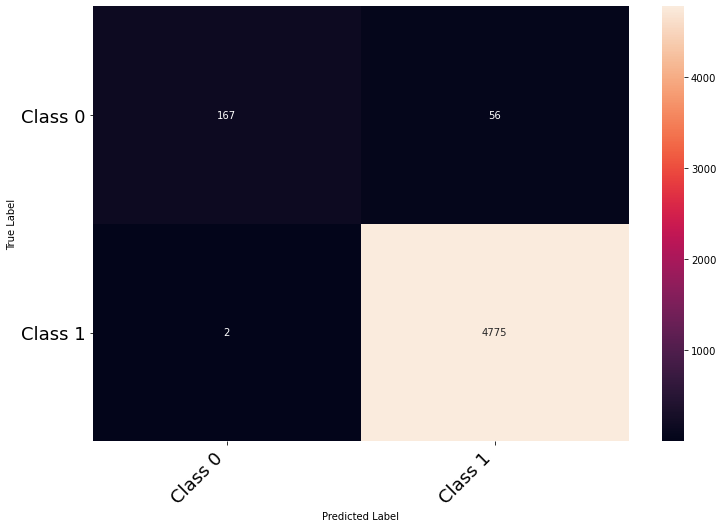

In [20]:
cm = print_confusion_matrix(confusion_matrix(y, svc_ros.predict(X)), ['Class 0', 'Class 1'])

**Daha iyi bir model!** Elimizdeki veri setine yalnızca random oversampling yöntemi uygulayarak azınlık olan sınıfımızda **18 tane veri noktasını** daha doğru sınıflandırmış olduk.

## 1.2. SMOTE (Synthetic Minority Oversampling Technique)

In [21]:
from imblearn.over_sampling import SMOTE
X_smoted, y_smoted = SMOTE().fit_resample(X,y)

In [22]:
Counter(y_smoted)

Counter({1: 4777, 0: 4777})

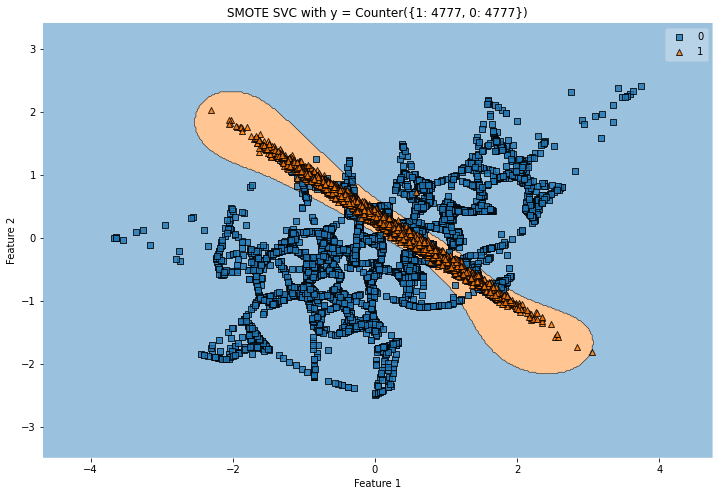

In [23]:
svg_smote = SVC().fit(X_smoted, y_smoted)
plot_decision_regions(X_smoted, y_smoted, svg_smote)
plt.title(f'SMOTE SVC with y = {Counter(y_resampled)}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.gcf().set_size_inches(12,8)

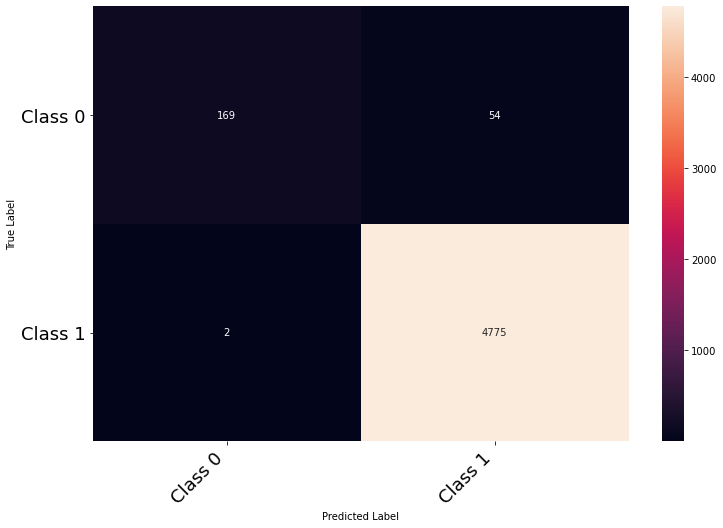

In [24]:
cm = print_confusion_matrix(confusion_matrix(y, svg_smote.predict(X)), ['Class 0', 'Class 1'])

Farklı bir yöntem kullanmamıza rağmen, oversampling yönteminde elde ettiğimiz sonuca oldukça benzer bir sonuç karşımıza çıktı. 

> **SORU:** Peki SMOTE yöntemi bizim için neyi farklı yaptı?

SMOTE, decision regionlara yakın noktalar ile ondan uzak noktalar arasında ayrım yapmaz. Böylece sınıflandırıcı için önemli olmayan alanlarda yeni noktalar oluşturulmuş olur.

## 1.3. ADASYN (Adaptive Synthetic Oversampling)

Bir diğer oversampling yöntemi ise ADASYN. Herhangi bir azınlık noktası arasında sentetik gözlemler üretmek yerine, **sınıf dengesizliğinin en fazla olduğu bölgelere** daha fazla önem verir. Başka bir deyişle, sınıflandırıcının çoğunluk sınıfı tahmin etme olasılığının en yüksek olduğu bölgelere odaklanır.

In [25]:
from imblearn.over_sampling import ADASYN
X_adasyn, y_adasyn = ADASYN().fit_resample(X,y)

In [26]:
Counter(y_adasyn)

Counter({1: 4777, 0: 4783})

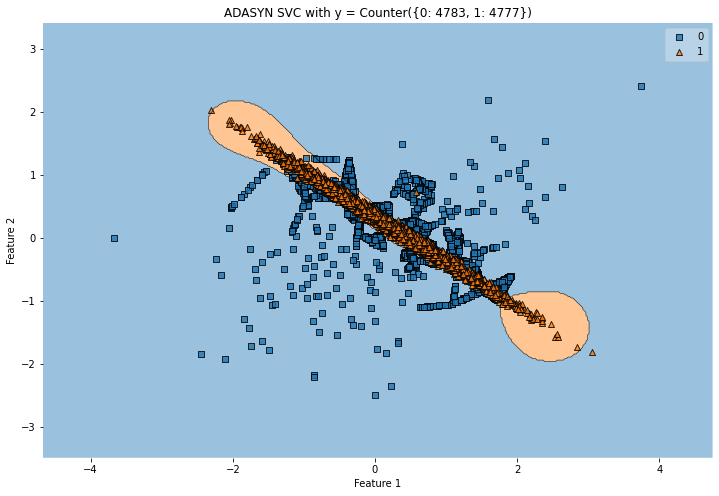

In [27]:
svg_adasyn = SVC().fit(X_adasyn, y_adasyn)
plot_decision_regions(X_adasyn, y_adasyn, svg_adasyn)
plt.title(f'ADASYN SVC with y = {Counter(y_adasyn)}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.gcf().set_size_inches(12,8)

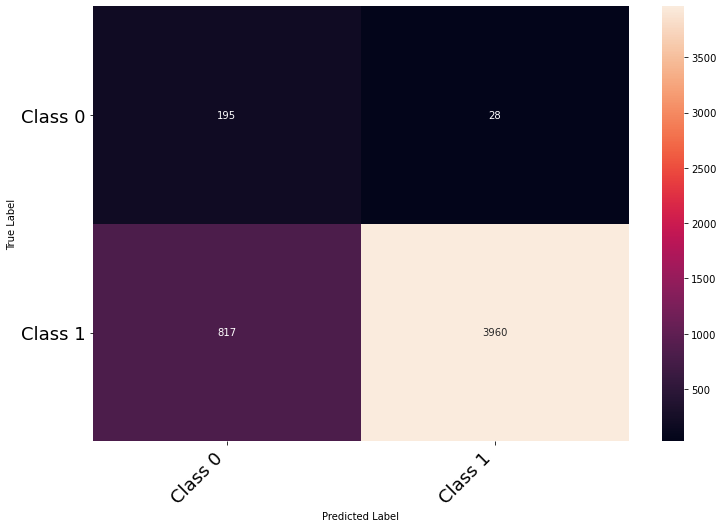

In [28]:
cm = print_confusion_matrix(confusion_matrix(y, svg_adasyn.predict(X)), ['Class 0', 'Class 1'])

> **SORU:** Tüm bu yöntemleri inceledikten sonra, sizce hangi oversampling yöntemi bizim veri setimizde en iyi sonucu verdi?

# 2. Yöntem - Undersampling

Undersampling yöntemi ise Oversampling'in tam tersidir. Bu yöntemde azınlık olan sınıftaki verileri arttırmak yerine **çoğunluk olan sınıftaki verilerin azaltılması** yaklaşımı izlenir. Bu sayede de, dengesiz veri seti sorunundan kurtulmuş oluruz.

Veri örneklerinin sayısını azaltmak, **modelin çalışma süresini de iyileştirebilir**, ancak undersampling yönteminin en büyük dezavantajlarından biri, **veri setimizdeki önemli bilgileri kaybedebilme** tehlikesidir. Bu sebeple, küçük veri setlerinde genellikle pek tercih edilmez.

In [29]:
from imblearn.under_sampling import RandomUnderSampler
X_under, y_under = RandomUnderSampler().fit_resample(X,y)

In [30]:
Counter(y_under)

Counter({0: 223, 1: 223})

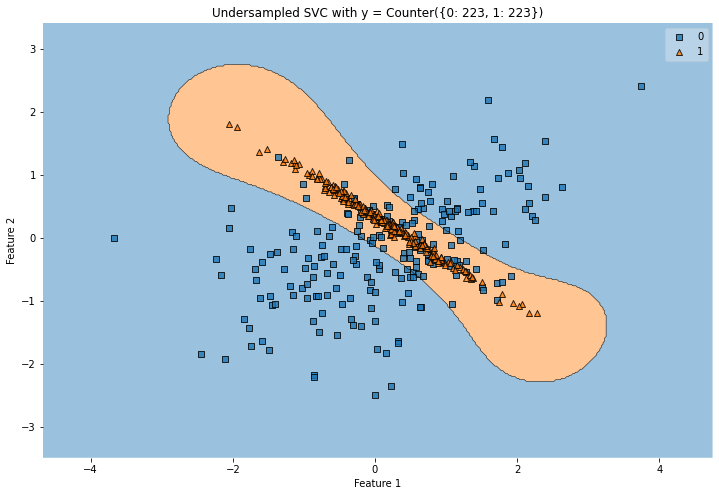

In [31]:
svg_rus = SVC().fit(X_under, y_under)
plot_decision_regions(X_under, y_under, svg_rus)
plt.title(f'Undersampled SVC with y = {Counter(y_under)}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.gcf().set_size_inches(12,8)

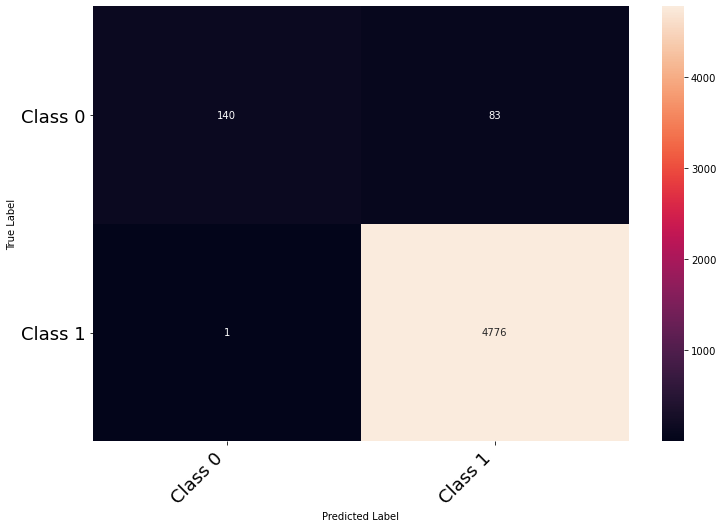

In [32]:
cm = print_confusion_matrix(confusion_matrix(y, svg_rus.predict(X)), ['Class 0', 'Class 1'])

## Multiclass (İkiden Fazla Sınıf) Problemleri

Oversampling ve Undersampling yöntemleri sadece binary classification problemlerinden geçerli değildir. Elimizde **2'den fazla hedef sütun değerimiz** olsa da bu yöntemleri kullanabiliriz. Şimdi de multiclass problemlerinde, şu ana kadar öğrendiğimiz yöntemlerin nasıl çalıştığına bakalım.

In [33]:
X, y = make_classification(n_samples=5000, n_features=2, n_informative=2,
                           n_redundant=0, n_repeated=0, n_classes=3,
                           n_clusters_per_class=1, 
                           weights=[0.01, 0.05, 0.94], # Bu sefer %1, %5 ve %94 yoğunlukta 3 adet sınıf tanımlıyoruz
                           class_sep=0.8, random_state=42)

In [34]:
df = pd.DataFrame(X, columns=['column1', 'column2'])
df['label'] = y

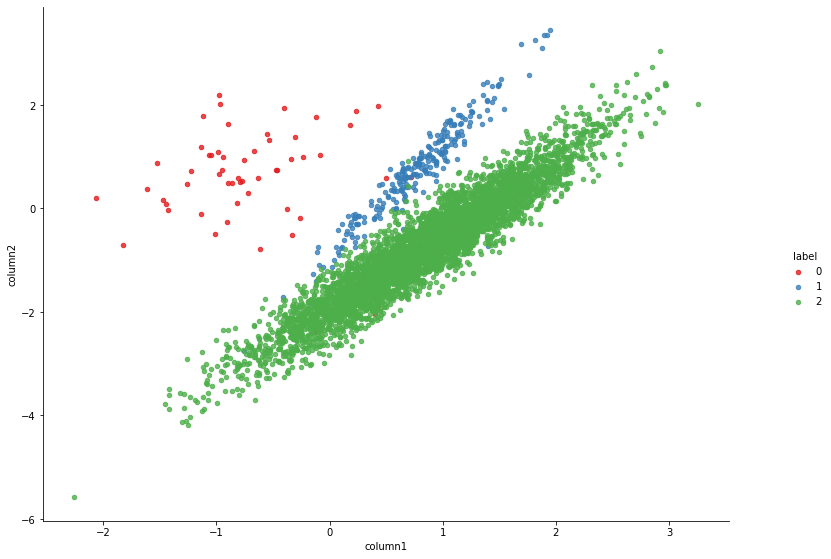

In [35]:
sns.lmplot(x='column1', y='column2', data=df, hue='label', palette='Set1', fit_reg=False, scatter_kws={'s': 20})
plt.gcf().set_size_inches(12,8)

Veri noktaları arasında oldukça doğrusal(lineer) ilişkiler var gibi duruyor. O yüzden bu örneğimizde **LinearSVC** algoritmasını kullanarak ilerleyelim.

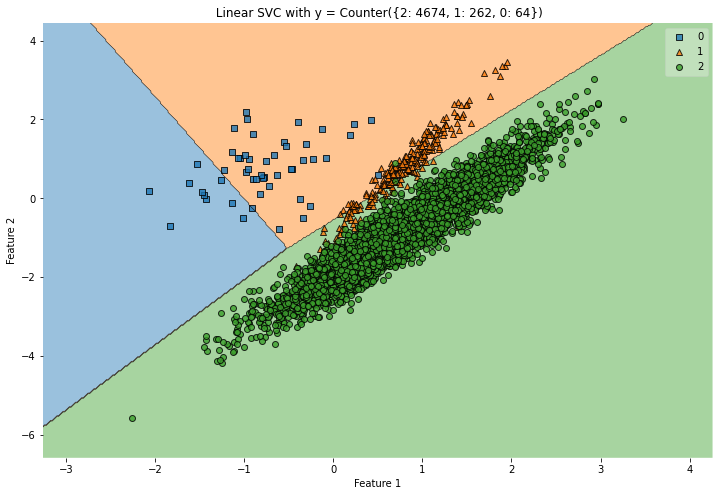

In [36]:
svg_multi = LinearSVC().fit(X, y)
plot_decision_regions(X, y, svg_multi)
plt.title(f' Linear SVC with y = {Counter(y)}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.gcf().set_size_inches(12,8)

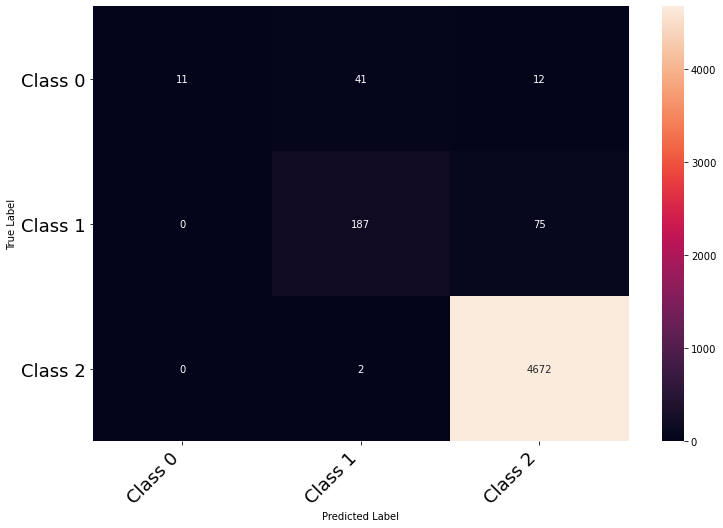

In [37]:
cm = print_confusion_matrix(confusion_matrix(y, svg_multi.predict(X)), ['Class 0', 'Class 1', 'Class 2'])

LinearSVC algoritmamız çoğunlukta olan sınıfı (Class 2) tahmin ederken oldukça başarılı olmasına rağmen, Class 1 ve Class 0'larda o kadar başarılı olamadığını görüyoruz. Ek olarak, Class 1'deki başarımız nispeten daha kabul edilebilir ancak Class 0'a geldiğimizde tahminlerimizde oldukça başarısız olduğumuzu görüyoruz.

Burada asıl soru şu: **Acaba modelimizi daha da iyileştirebilir miyiz?** Hemen öğrendiğimiz yöntemleri bu problemlerimizde de uygulayalım ve elde ettiğimiz sonuçları tartışalım.

In [38]:
ros = RandomOverSampler()
X_resampled, y_resampled = ros.fit_resample(X,y)

In [39]:
Counter(y_resampled)

Counter({2: 4674, 1: 4674, 0: 4674})

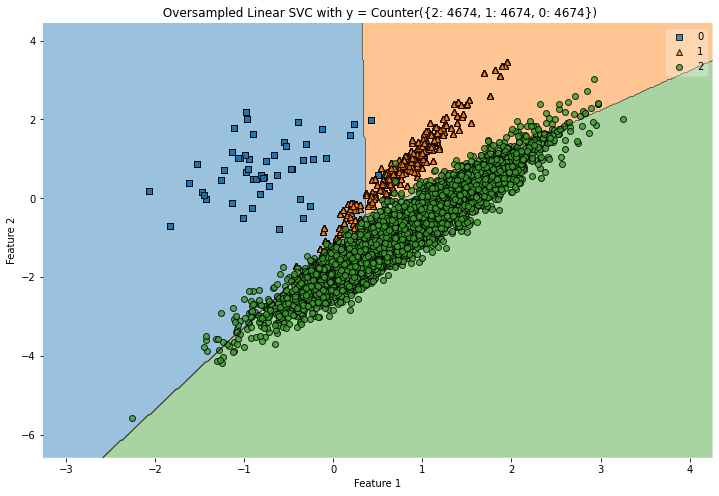

In [40]:
svg_multi_ros = LinearSVC().fit(X_resampled, y_resampled)
plot_decision_regions(X_resampled, y_resampled, svg_multi_ros)
plt.title(f' Oversampled Linear SVC with y = {Counter(y_resampled)}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.gcf().set_size_inches(12,8)

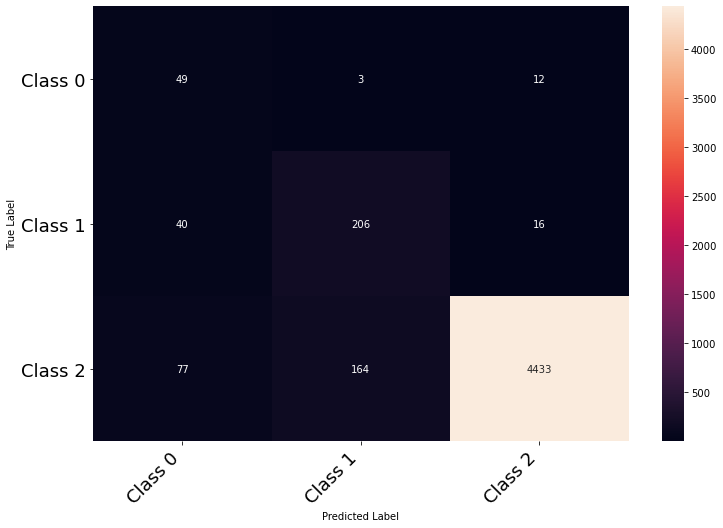

In [41]:
cm = print_confusion_matrix(confusion_matrix(y, svg_multi_ros.predict(X)), ['Class 0', 'Class 1', 'Class 2'])

**Random Oversampling** yönteminden elde ettiğimiz sonuçları orijinal modelimizle kıyaslandığımızda, Class 2'deki başarı oranımızın düşmesine rağmen Class 1 ve Class 0'da ciddi iyileşmeler olduğunu görüyoruz.

| Sınıflar    | İlk Model | Random Oversampling |
|------------ | --------- | ------------------- |
| **Class 0** | **%17**   | **%76**             |
| **Class 1** | **%71**   | **%79**             |
| **Class 2** | **%99**   | **%95**             |

Bir de ADASYN yönteminden elde edeceğimiz sonuçlara bakalım.

In [42]:
X_adasyn, y_adasyn = ADASYN().fit_resample(X,y)

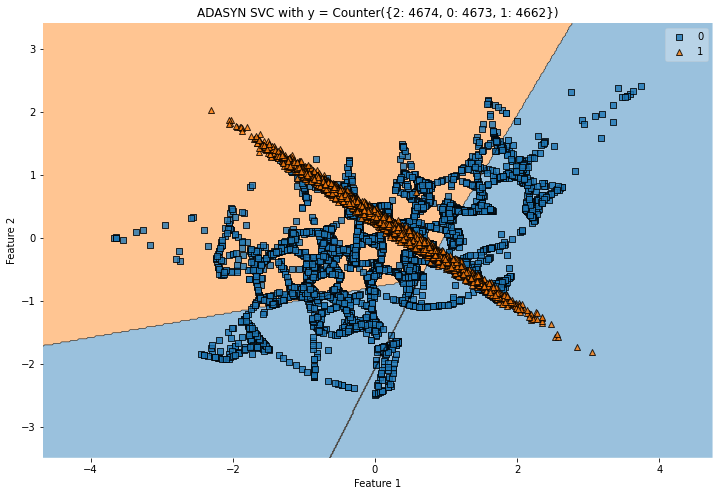

In [43]:
svg_multi_smote = LinearSVC().fit(X_adasyn, y_adasyn)
plot_decision_regions(X_smoted, y_smoted, svg_multi_smote)
plt.title(f'ADASYN SVC with y = {Counter(y_adasyn)}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.gcf().set_size_inches(12,8)

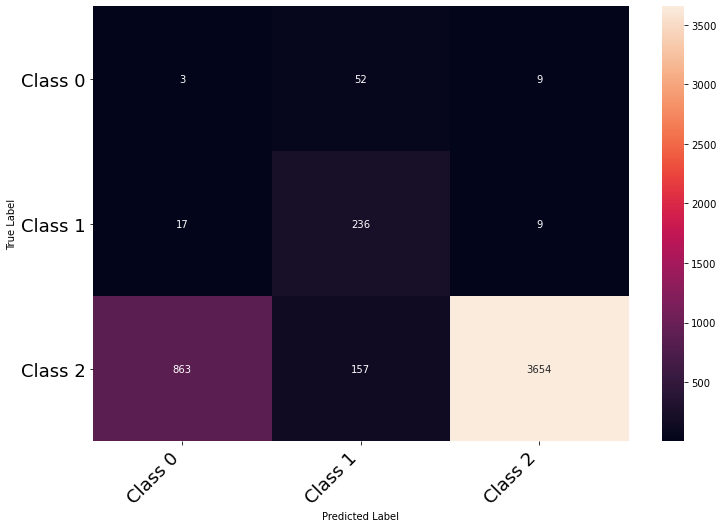

In [44]:
cm = print_confusion_matrix(confusion_matrix(y, svg_multi_smote.predict(X)), ['Class 0', 'Class 1', 'Class 2'])

**ADASYN** yönteminden elde ettiğimiz sonuçları Random Oversampling modelimizle kıyaslandığımızda, Class 2'deki başarı oranımızın düştüğü ancak buna karşın Class 1 ve Class 0'daki başarı oranlarında iyileşmeler olduğunu görüyoruz.

| Sınıflar    | İlk Model | Random Oversampling | ADASYN  |
|------------ | --------- | ------------------- | ------- |
| **Class 0** | **%17**   | **%76**             | **%81** |
| **Class 1** | **%71**   | **%79**             | **%90** |
| **Class 2** | **%99**   | **%95**             | **%78** |

> **SORU:** Elde edilen bu sonuçlara göre siz hangi modeli kullanmayı tercih ederdiniz?

Dengesiz veri setleriyle çalışırken genel olarak şu adımları izleyebilirsiniz:

**1. Hiçbir Şey Yapmamak!**
- Evet yanlış duymadınız. Bazı durumlarda sınıflandırma algoritmalarımız şanslı bir şekilde dengesiz veri dağılımlarının üstesinden gelebilir. Keyfinize bakabilirsiniz :)

**2. Öğrendiğimiz Yöntemleri Uygulamak!**
- Eğer veri setinizde yeterli miktarda çeşitlilik varsa ilk olarak, **Random Oversampling** yöntemini uygulayarak azınlık olan sınıftaki örnek sayımızı arttırabiliriz.
- Random Oversampling yöntemi istediğiniz sonucu size vermedi mi? Öğrendiğimiz **diğer Oversampling yöntemlerini (SMOTE & ADASYN)** kullanıp onlardan elde ettiğiniz sonuçlara bakabiliriz.
- Eğer çok büyük boyuttaki veri kümeleriyle çalışıyorsanız ve Oversampling uygulamak hesap yükünüzü çok arttıracaksa, o zaman **Random Undersampling** yönteminden de yararlanabiliriz.

## Sıra Sizde

Kendi oluşturduğumuz veri setleri için yaptığımız bu çalışmayı, **örnek(train.csv) veri seti** üzerinden de deneyip oradan elde ettiğiniz sonuçları tartışın.